# Veri Biliminde Outlier / Aykırı Değer Tespiti

**Dersin Amaçları**</br>
<ul>
<li>Aykırı değer (outlier) kavramını anlamak — neden oluşur, neden önemli.</li>

<li>Farklı outlier tespit yöntemlerini bilmek: istatistiksel, görsel, makine öğrenimi tabanlı.</li>

<li>Python ile gerçek veri üzerinden outlier tespiti yapmak.</li>

<li>Outlier’ları nasıl ele alabileceğimizi (çıkarma, dönüştürme, işaretleme vs.) göstermek.</li>

<li>Outlier yönetiminin veri analizi ve modelleme sonucuna etkisini fark etmek.</li>
</ul>

**Outlier / Aykırı Değer Nedir?**</br>

**Tanım:** Aykırı değer, veri setindeki diğer gözlemlerden “bariz” biçimde farklı olan, genel veri yapısını bozabilen gözlemdir.</br>

**Neden ortaya çıkar?**</br>

<ul>
    <li>Ölçüm / veri girişi hatası (yanlış değer girilmesi)</li>
    <li>Doğal farklılık / nadir durumlar (örn. gelir dağılımında çok yüksek değer)</li>
    <li>Veri toplama hatası, sensor hatası, temizlenmemiş veri vb. </li>
</ul>

**Neden önemli?** Aykırı değerler: ortalamayı, standart sapmayı, korelasyonları, regresyon katsayılarını çarpıtabilir; makine öğrenimi modellerini bozabilir; özet istatistikleri yanıltabilir.</br>

**Outlier türleri:**</br>
<ul>
    <li>Univariate outlier: tek değişkende aşırı değer</li>
    <li>Multivariate / çok değişkenli outlier: birkaç değişkenin kombinasyonu ile sıra dışı nokta</li>
    <li>Local outlier: genel dağılıma göre değil, komşu gözlemlere göre anormal (yoğunluk temelli)</li>
</ul>
---

## 📌 Outlier Türleri: Temel Kavramlar & Farklar

### 🔹 **Univariate outlier**

* Tek bir değişkene (feature / sütun) bakarak tespit edilen aykırı değer. 
* “Bu değişkende bu gözlem diğerlerinden çok farklı” diyorsak — örneğin bir öğrencinin notu diğer tüm öğrencilerden çok yüksek ya da çok düşükse — bu bir univariate outlier’dır.
* Avantajı: Basit, yorumlaması kolay, tek değişkenli dağılımlar üzerinde hızlı çalışan yöntemlerle kolayca belirlenebilir. Örneğin **Z-skor**, **IQR / box-plot** gibi yöntemler. 
* Sınırlılığı: Eğer veride birden çok değişken varsa ve anormallik sadece “bir tek değişkende değil, değişkenler kombinasyonunda” ortaya çıkıyorsa, univariate yöntem bunu yakalamaz.

---

### 🔹 **Multivariate outlier**

* Bir gözlem birden fazla değişkenin kombinasyonuyla “alışılmadık / sıra dışı” ise — ancak tek tek değişkenlerde uç değer olarak görünmeyebilir — bu bir multivariate outlier’dır. 
* Örneğin: Bir evin metrekaresi ve oda sayısı normal aralıkta; ancak “şehir merkezine uzaklık” + “yaş” + “fiyat” kombinasyonu düşünüldüğünde, bu ev “normal” evlere göre sıra dışı olabilir. Tek bir değişken bazında aykırı görünmeyebilir ama kombinasyon aykırıdır.
* Tespit için genelde **çok değişkenli mesafe / dağılım temelli** ya da **istatistiksel yöntemler** kullanılır. Örneğin **Mahalanobis distance** bu amaçla yaygındır. 
* Yüksek boyutlu veri setlerinde univariate yöntemlerin kaçırdığı “gizli aykırı değer”leri yakalamada etkilidir. Ancak yorumlaması, görselleştirmesi ve anlaşılması univariate kadar basit değildir.

---

### 🔹 **Local outlier** (Yoğunluk / Komşuluk Temelli Aykırı Değer)

* Bu kavram “global dağılımdaki aykırılık” yerine **lokal yoğunluk** temeline bakar. Yani bir gözlem, tüm veri setine göre değil, **k-komşularına göre** sıradışı olabilir.
* Özellikle veri setinde **birden fazla yoğunluklu küme (cluster)**, farklı alt gruplar varsa veya dağılım çok modluysa — global outlier tespiti yanıltıcı olabilir. Local outlier metotları bu durumda daha sağlıklıdır. 
* Örnek yöntem: **LocalOutlierFactor (LOF)** — her gözlem için “local reachability density” hesaplar; eğer yoğunluğu komşularına göre anlamlı düşükse → outlier. 
* Avantajı: Kümeleşmiş, heterojen, çok modlu ya da karma dağılımlı veri setlerinde güçlü; hem global hem de lokal anormallikleri yakalayabilir.
* Dezavantaj / dikkat: Parametre seçimi (komşu sayısı, contamination oranı vb.) kritik; yorumlama “komşu yoğunluğu vs global dağılım” anlayışı gerektirir.

---

## ✅ Ne Zaman Hangi Türü Kullanmalı?

| Durum / Özellik                                                                           | Uygun Outlier Türü                                                   |
| ----------------------------------------------------------------------------------------- | -------------------------------------------------------------------- |
| Veri tek değişken — ya da değişkenleri bağımsız ele alıyoruz                              | Univariate outlier (Z-score, IQR, box-plot…)                         |
| Veri çok değişkenli, değişkenler arası ilişki önemli, kombinasyonlar sıra dışı olabilir   | Multivariate outlier (Mahalanobis, çok değişkenli mesafe yöntemleri) |
| Veri kümeler halinde, yoğunluk farkları var, kümeler arası heterojenlik / küme yapısı var | Local outlier (LOF, density-based, komşuluk tabanlı)                 |

---

## 🔄 Özet / Kavramsal Karşılaştırma

* **Univariate outlier** → tek değişken + uç değer
* **Multivariate outlier** → değişkenler kombinasyonu + sıra dışı kombinasyon
* **Local outlier** → global dağılımdan değil; **komşu / yoğunluk bağlamından** bakılan anormallik

Bu yüzden — analiz öncesi veri setini incelerken — hangisinin (veya hangilerinin) anlamlı olabileceğini değerlendirmek çok önemli.

---

İstersen — bu üç outlier türü için **3 farklı Python + grafik + yorum örneği** hazırlayabilirim — hem kavramsal farkı hem uygulama farkını görsel + sayısal olarak ortaya koyarız. Nasıl olur?

[1]: https://www.statisticssolutions.com/univariate-and-multivariate-outliers/?utm_source=chatgpt.com "Univariate and Multivariate Outliers"
[2]: https://ravenfo.com/2021/02/11/aykiri-deger-analizi/?utm_source=chatgpt.com "Aykırı Değer (Outlier) Analizi Nedir? Uç Değerler Nasıl ..."
[3]: https://en.wikipedia.org/wiki/Mahalanobis_distance?utm_source=chatgpt.com "Mahalanobis distance"
[4]: https://medium.com/machine-learning-t%C3%BCrkiye/anomaly-tespiti-3-d3502cbcce64?utm_source=chatgpt.com "ANOMALY TESPİTİ -3. LOCAL OUTLIER FACTOR (LOF)"
[5]: https://www.veribilimiokulu.com/local-outlier-factor-ile-anormallik-tespiti/?utm_source=chatgpt.com "Local Outlier Factor ile Anormallik Tespiti"













**Outlier tespiti  nedenleri**</br>

<ul>
    <li>Veri ön işleme / temizleme</li>
    <li>Modelleme öncesi — özellikle regresyon, istatistik vs.</li>
    <li>Veri kalitesi değerlendirmesi</li>
</ul>


**Yaygın Outlier Tespit Yöntemleri**</br>

| Yöntem                                                                                          | Ne zaman uygundur / avantajı                                                                                             |
| ----------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------ |
| **Görselleştirme** — Boxplot, Histogram, Scatter, vs                                            | İlk keşif / hızlı görsel kontrol. Aykırı değerlerin varlığını sezmek için.                   |
| **Z-Score / Standart Sapma Yöntemi**                                                            | Veri yaklaşık normal dağılmışsa; basit & hızlı.                                                      |
| **Çeyrekler Açıklığı (IQR) / Tukey Metodu**                                                     | Dağılım bilinmeyen veya çarpıksa; ortanca ve çeyrekler temeline dayandığı için daha sağlam.  |
| **Yoğunluk / Komşuluk Tabanlı Yöntemler (örneğin Local Outlier Factor (LOF))**                  | Çok değişkenli veri; tek değişken bazlı yöntem yeterli olmayabilir.                                      |
| **Model / Makine Öğrenimi Tabanlı Yöntemler** — Örneğin Isolation Forest, kümeleme yöntemleri, vs. | Yapısal / karmaşık veri; yüksek boyutlu veri; klasik yöntemlere uymayan durumlarda.                     |



In [1]:
# Örnek Veri Seti Hazırlığı
import pandas as pd
import numpy as np

np.random.seed(0)
# Normal + biraz aşırı uç değer
values = np.concatenate([
    np.random.normal(50, 10, 200),     # normal dağılım
    np.random.normal(100, 5, 5),       # yüksek uç değerler
    np.random.normal(10, 5, 5)         # düşük uç değerler
])
df = pd.DataFrame({"value": values})
df.to_csv("outlier_demo.csv", index=False)


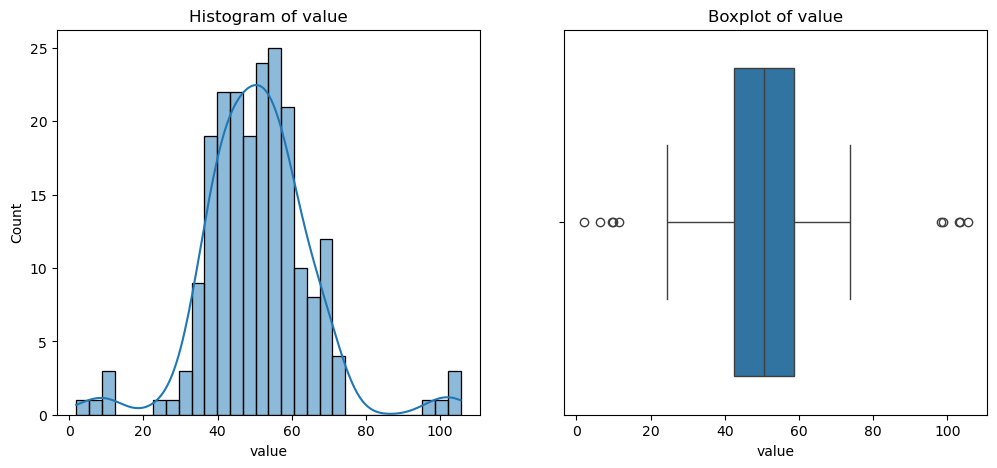

In [2]:
# 1. Görselleştirme + Boxplot / Histogram
# Amaç: Görsel olarak uç değerleri, dağılımın kuyruklarını fark etmek.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("outlier_demo.csv")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df["value"], bins=30, kde=True)
plt.title("Histogram of value")

plt.subplot(1,2,2)
sns.boxplot(x=df["value"])
plt.title("Boxplot of value")

plt.show()


In [3]:
# 2. Z-Score Yöntemi ile Aykırı Değer Tespiti

# Z-score > 3 veya < –3 → genelde aykırı olarak kabul edilir.

# Ne zaman uygundur? Veri yaklaşık normal dağılmışsa; aşırı uç değerler değil de daha “ölçek dışı” değer ararken.


from scipy.stats import zscore

df["z_score"] = zscore(df["value"])
outliers_z = df[np.abs(df["z_score"]) > 3]
print("Z-score ile belirlenen outlier’lar:", outliers_z)


Z-score ile belirlenen outlier’lar:           value   z_score
200   98.154091  3.294201
201   98.803104  3.339449
202  105.498298  3.806224
203  103.276319  3.651312
204  103.200658  3.646037
205    1.915220 -3.415370
207    6.309845 -3.108986


In [4]:
# 3. IQR / Tukey Metodu ile Aykırı Değer Tespiti

# IQR metodu, dağılım şekli ne olursa olsun (çarpık, simetrik) güçlü ve yaygın kullanılan bir yöntemdir. 

Q1 = df["value"].quantile(0.25)
Q3 = df["value"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["value"] < lower_bound) | (df["value"] > upper_bound)]
print("IQR ile belirlenen outlier’lar:", outliers_iqr)


IQR ile belirlenen outlier’lar:           value   z_score
200   98.154091  3.294201
201   98.803104  3.339449
202  105.498298  3.806224
203  103.276319  3.651312
204  103.200658  3.646037
205    1.915220 -3.415370
206    9.878369 -2.860196
207    6.309845 -3.108986
208   11.399623 -2.754137
209    9.509248 -2.885930


           x1        x2  outlier
200  4.202786  4.700312     True
201  5.002622  5.023490     True
202  4.774967  5.311425     True
203  4.466190  4.928810     True
204  5.060148  5.257219     True


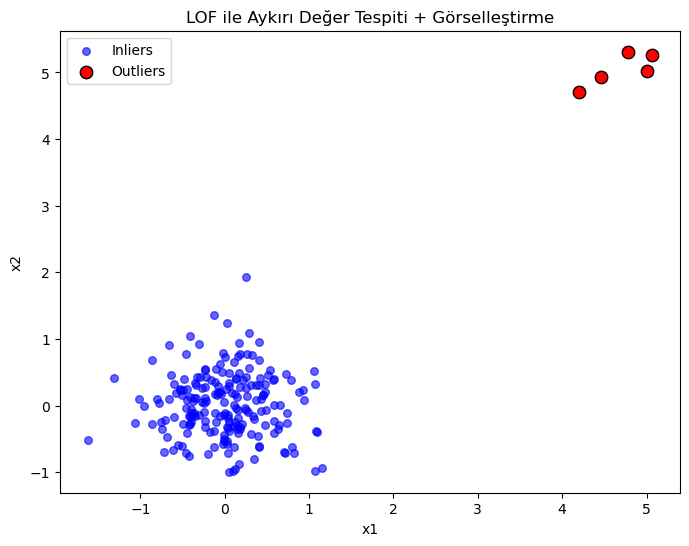

In [9]:
from sklearn.neighbors import LocalOutlierFactor  
import numpy as np  
import pandas as pd 

# --- Simüle veri oluşturma ---
rng = np.random.RandomState(42)  
# RandomState ile reproducible (tekrarlanabilir) rastgele sayı üreticisi oluşturduk — aynı rastgele sayılar her çalışmada üretilir.

# “Normal / inlier” veri: 200 örnek, 2 değişkenli, ortalama 0, standart sapma 0.5
X_inliers = rng.normal(0, 0.5, size=(200, 2))

# “Aykırı / outlier” veri: 5 örnek, 2 değişkenli, ortalama 5, standart sapma 0.5 → bu noktalar diğerlerinden oldukça farklı
X_outliers = rng.normal(5, 0.5, size=(5, 2))

# Inlier ve outlier verilerini tek numpy dizisinde birleştiriyoruz
X = np.vstack([X_inliers, X_outliers])

# Numpy dizisini pandas DataFrame’e çeviriyoruz, kolon isimlerini “x1”, “x2” yapıyoruz
df2 = pd.DataFrame(X, columns=["x1", "x2"])

# --- LOF Modeli (Yerel Aykırı Değer Algılama) ---

# LOF nesnesini tanımlıyoruz. Parametreler:
#   n_neighbors=20 → Her nokta için 20 en yakın komşusuna bakar.
#   contamination=0.02 → Veri setindeki yaklaşık %2 kadar gözlemin aykırı olabileceğini varsayar. Buna göre eşik belirlenir. 
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)

# fit_predict ile hem modele “uygula” hem de her gözlem için -1 (outlier) / 1 (inlier) etiketi üret
y_pred = lof.fit_predict(df2)

# DataFrame’e yeni bir kolon ekle: outlier — True ise outlier, False ise inlier
df2["outlier"] = (y_pred == -1)

# Aykırı olduklarını tespit ettiği gözlemleri yazdır
print(df2[df2["outlier"]])

# 3. Görselleştirme
plt.figure(figsize=(8,6))
# Inlier’lar
plt.scatter(
    df2.loc[~df2["outlier"], "x1"],
    df2.loc[~df2["outlier"], "x2"],
    c="blue",
    label="Inliers",
    s=30,
    alpha=0.6
)
# Outlier’lar
plt.scatter(
    df2.loc[df2["outlier"], "x1"],
    df2.loc[df2["outlier"], "x2"],
    c="red",
    label="Outliers",
    s=80,
    edgecolor="k"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("LOF ile Aykırı Değer Tespiti + Görselleştirme")
plt.legend()
plt.show()

**Outlier’lara Ne Yapmalı? Temel Stratejiler**</br>

**Çıkarma (drop):** Temizleme, analiz kalitesini arttırır; ancak “gerçek ekstrem değerleri” yanlışlıkla silmemeye dikkat.</br>

**Dönüştürme (transform):** Log, sqrt gibi dönüşümlerle aşırı uçların etkisini azaltmak.</br>

**İşaretleme (flagging):** “Bu gözlem outlier” etiketi eklemek → modelde outlier bilgisini kullanılabilir yapmak ya da ayrı analiz.</br>

**Robust metodlar kullanmak:** Medyan, IQR, robust scaler, ağaç tabanlı modeller vb.</br>



## 🔸 Outlier Yönetiminde “İşaretleme (Flagging)” Nedir & Ne İşe Yarar?

### Ne demek: “Flagging”
* Outlier tespit edildikten sonra bu gözlemi veri kümesinden *silmek* yerine, ona bir “etiket / bayrak (flag)” koyarsınız — mesela bir boolean (True/False) kolon: is_outlier = True.
* Bu yolla, gözlemi tamamen yok etmemiş olursunuz; ama modelleme, analiz ya da raporlama aşamasında **outlier’ları ayrı değerlendirme** imkânınız olur.

### Ne avantajı var?

| Durum / Avantaj                                                       | Neden önemli                                                                                                                  |
| --------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| Outlier’lar aslında değerli / anlamlı olabilir                        | Örneğin gelir zirveleri, nadir olaylar, uç kullanıcı davranışları — gerçek “anormallik” olabilir, silmek bilgi kaybı olabilir |
| Modelin bu gözlemleri bilerek işlemesi isteniyorsa                    | Flag kolonuyla outlier’lığı model girdisi olarak verebilir — model “diğerlerinden farklı” gözlemleri ayrı değerlendirebilir   |
| Veri temizliği sonrası “temiz” + “kirli” veriyi kıyaslamak isterseniz | Hangi analiz / model outlier’lardan ne kadar etkileniyor görebilirsiniz                                                       |
| Şeffaflık & yeniden üretilebilirlik                                   | “Hangi gözlemleri outlier saydık / hangilerini çıkardık / neden” açıkça izlenebilir olur — etik / akademik analizlerde kritik |

### Örnek: Python ile Flagging

Örneğin daha önce yaptığımız LOF ile:

```python
df["is_outlier"] = (y_pred == -1)
```

— Bu şekilde `is_outlier` boolean kolonu eklemiş olduk. Sonrasında:

* `df_clean = df[df["is_outlier"] == False]` → outlier’ları çıkarmış olan “temiz” veri
* `df_outliers = df[df["is_outlier"] == True]` → outlier gözlemleri ayrı analiz / raporlama / inceleme için ayırabilir
* Modellerde `is_outlier` özelliğini (feature) kullanarak outlier etkisini modelde yakalayabilirsiniz

### Ne Zaman Flagging Kullanmalı?

* Outlier’lar silinemez / bilgi içerebilir (örneğin finansal uç değer, nadir hastalık vakası, müşterilerin tipik olmayan davranışı)
* Veri seti yeterince büyük değil — silme modelin genellenebilirliğini düşürebilir
* Outlier’lar üzerinde ayrıca analiz yapmak / raporlamak / yorumlamak isteniyor

---

## 🔸 Robust Metotlar — Nedir? Neler Var? Ne Avantajı Var?

###  “Robust” Ne Demek?

“Robust” terimi, **ayırt edilebilir sapmalara / aykırı değerlere karşı dayanıklı** anlamında kullanılır. Yani, veri içinde outlier olsa bile, sonuçları onlardan “çok fazla etkilenmeyen” istatistiksel yöntemler, modeller ya da dönüşümler. Bu yaklaşımlar “verinin çoğunluğunu hedef alır, aşırı uçları bastırır veya etkisini azaltır”. 

Bu yüzden “robust statistics / robust estimation” kavramı, klasik yöntemlerin (ortalama, standart sapma, OLS regresyon vb.) yetersiz kaldığı durumlarda başvurulan güçlü bir alternatiftir. 

### Bazı Yaygın Robust Yöntemler

| Yöntem / Teknik                                                                                     | Ne Yapar / Neden “Robust”?                                                                                                                                                       |
| --------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Median / IQR / MAD** (mean + std yerine)                                                          | Ortalama ve standart sapma yerine medyan + IQR (ya da Median Absolute Deviation) kullanır — uç değerlerin etkisini büyük ölçüde sınırlar.                       |
| **RobustScaler** (scikit-learn)                                                                     | Standartlaştırma / ölçekleme yaparken ortalama/standart sapma değil, medyan ve IQR kullanır — outlier’lardan bağımsız ölçekleme.                         |
| **Robust Regresyon Yöntemleri** (örneğin RANSAC Regression, Theil‑Sen Regression, Huber Regression) | Aykırı gözlemlere küçük ağırlık ya da hiç katkı vermeyerek modeli “çoğunluğa göre” uyarlar — böylece outlier’lar sonucun sürüklendiği yer olmaz.       |
| **Ağaç-tabanlı / Ensemble Modeller** (RandomForest, GradientBoosting vb.)                           | Bu modeller, parametric varsayımlar (normal dağılım, sabit varyans vs) gerektirmez, bu nedenle outlier’lara karşı daha toleranslı olabilir (özellikle hedef değişkende değilse). |
| **İstatistiksel Doluluk / Winsorization / Clipping**                                                | Aykırı değerleri tamamen silmek yerine — onları uçların biraz daha makul sınırlarına “sıkıştırmak”. Örneğin yüksek / düşük yüzde dilimlerine set etmek.        |

### Neden Robust Yöntem?

* Outlier’ların varlığı **analiz & model sonuçlarını çarpıtabilir**. Özellikle ortalama, varyans, regresyon katsayıları gibi hassas ölçümler. 
* Robust yöntemler sayesinde, **çoğunluğun temsil ettiği yapıyı doğru biçimde yakalayabiliriz**, “anakütle” analizinde sapma olmaz. 
* Outlier’lar aslında bilgi olabilir — tamamen silmek bilgi kaybı demek olabilir. Robust yöntemlerle hem bu bilgi korunur, hem analizin güvenilirliği sağlanır.

---

## Ne Zaman Flagging / Robust Yapmalı — Hangisi Hangi Durum İçin Daha Uygun?

* Veri setiniz büyük ve outlier sayısı az — ama bilgi değerli → **Flagging** + gerekirse robust modeller
* Outlier’lar ölçüm hatasından değil, gerçek uç değerlerden geliyorsa (örneğin gelir, yaş, gelgit verisi…) → **Robust yöntemler**
* Modellemek istediğiniz problem parametric regresyon, istatistiksel analiz vs ise — klasik yöntemlerin varsayımları bozuluyorsa → **Robust Regresyon / RobustScaler**

---

## Öneriler

* “Outlier = hep silinecek yanlış veri” diye düşünmemek — bazen **değerli “uç bilgi”** olabilir.
* Veri temizliği yaparken **karar bilinçli** olmalı: neden siliyorsunuz / neden dönüştürüyorsunuz / neden robust yöntem seçiyorsunuz.
* Her yöntem artı-eksi taşır; **çözüm değil, strateji** seçiyorsunuz.
* Uygulamada — RobustScaler, robust regresyon, flagging gibi yöntemlerle **çift yönlü güvenlik** (hem veri kaybı olmadan hem modele dayanıklı) sağlanabilir.

---
